# <center> Domain Name Suggestions

## 1. Synthetic Dataset Creation

In [ ]:
# Dependancies installation 
!pip install -r requirements.txt

  Using cached peft-0.17.0-py3-none-any.whl.metadata (14 kB)
Using cached peft-0.17.0-py3-none-any.whl (503 kB)

[notice] A new release of pip is available: 24.3.1 -> 25.2
[notice] To update, run: pip install --upgrade pip


In [ ]:
# Rule Based dataset generation

from data.utils import save_dataset
from data.config import OUTPUT_FILE
from data.rule_based_dataset_generation import generate_dataset

dataset = generate_dataset()
save_dataset(dataset, filename=OUTPUT_FILE)

In [ ]:
# LLM dataset generation
from data.utils import load_model, save_dataset, get_device
from data.config import MODEL_NAME

DEVICE = get_device()

generator = load_model(MODEL_NAME, DEVICE)
data = generate_dataset(generator, num_examples=2)
save_dataset(data)

## 2. Model Development & Iteration

In [6]:
# Running an experiment from a config file
# Hyperparameter optimization by optuna is used
import sys
sys.path.append("experiments")
from experiments.run_hpo import main

config_path = "config_files/hpo_config.yaml"
main(config_path)

[I 2025-08-10 19:12:04,285] A new study created in memory with name: no-name-af55fbbb-b509-4b0a-8da4-409e1286583f


2025-08-10 19:12:04,297 - finetuner - INFO - Initializing FineTuner...
2025-08-10 19:12:04,297 - utils - INFO - Apple Silicon device detected. Using 'mps' backend.
2025-08-10 19:12:04,297 - finetuner - INFO - Loading and preparing dataset...
2025-08-10 19:12:04,298 - data_processing - INFO - Loading dataset from generated_data.json


2025-08-10 19:12:04,587 - data_processing - WARNING - Using DEBUG subset of 500 examples


Map: 100%|██████████| 500/500 [00:00<00:00, 28126.66 examples/s]

2025-08-10 19:12:04,610 - data_processing - INFO - Prepared dataset with columns: ['text']
2025-08-10 19:12:04,610 - finetuner - INFO - Loading base model 'google/gemma-2b'


...

2025-08-10 19:40:24,501 - finetuner - INFO - Fine-tuning finished.
2025-08-10 19:40:24,501 - finetuner - INFO - Evaluating model...


/Users/abdessamadlachgar/Dev/.venv-1/lib/python3.13/site-packages/torch/utils/data/dataloader.py:683: UserWarning: 'pin_memory' argument is set as true but not supported on MPS now, then device pinned memory won't be used.
  warnings.warn(warn_msg)


2025-08-10 19:40:30,209 - finetuner - INFO - Saving model to results/trial_4...
2025-08-10 19:40:30,995 - finetuner - INFO - Model saved successfully.


[I 2025-08-10 19:40:31,394] Trial 4 finished with value: 1.3514480590820312 and parameters: {'learning_rate': 1.6577256119585803e-05}. Best is trial 0 with value: 0.7334606051445007.


2025-08-10 19:40:31,395 - experiments.run_hpo - INFO - Best trial #0 with loss 0.7334606051445007
2025-08-10 19:40:31,395 - experiments.run_hpo - INFO -  → Local checkpoint: results/trial_0
2025-08-10 19:40:31,395 - experiments.run_hpo - INFO -  → MLflow run ID: 8dbb1442f1854502ab1bd282f068b61e
2025-08-10 19:40:36,562 - experiments.run_hpo - WARNING - Could not plot HPO: Tried to import 'plotly' but failed. Please make sure that the package is installed correctly to use this feature. Actual error: No module named 'plotly'.


In [4]:
import subprocess, time
from IPython.display import IFrame

# Start MLflow UI in background
mlflow_proc = subprocess.Popen(
    ["mlflow", "ui", "--port", "5001", "--backend-store-uri", "./mlruns"],
    stdout=subprocess.PIPE, stderr=subprocess.PIPE
)

time.sleep(3)  # Wait for UI to start

# Show in notebook
IFrame(src="http://127.0.0.1:5001", width="1000", height="600")

huggingface/tokenizers: The current process just got forked, after parallelism has already been used. Disabling parallelism to avoid deadlocks...
To disable this warning, you can either:
	- Avoid using `tokenizers` before the fork if possible
	- Explicitly set the environment variable TOKENIZERS_PARALLELISM=(true | false)


## 3. LLM-as-a-Judge Evaluation Framework

In [7]:
import json
from evaluation.llm_judge import LLMDomainJudge

def test_llm_judge():
    description = "An online marketplace for buying and selling handmade skincare."
    # Using more realistic, brandable names for a better test case
    predictions = [
        {"domain": "artisanskin.com", "confidence": 0.92},
        {"domain": "purelycrafted.co", "confidence": 0.88},
        {"domain": "theglowfoundry.market", "confidence": 0.83},
    ]

    # Note: Using gemma-2b-it is highly recommended for better instruction following
    judge = LLMDomainJudge(model_id="mistralai/Mistral-7B-Instruct-v0.2")
    result = judge.rate_predictions(description, predictions)

    print("\n === Judge Result === ")
    print(json.dumps(result, indent=2))

    # Example of poor domains
    print("\n--- Testing with poor domains ---")
    poor_predictions = [
        {"domain": "cofee.com", "confidence": 0.92},
        {"domain": "salad.co", "confidence": 0.88},
        {"domain": "Ndw.mat", "confidence": 0.83},
    ]
    poor_result = judge.rate_predictions(description, poor_predictions)
    print("\n === Judge Result (Poor) === ")
    print(json.dumps(poor_result, indent=2))

In [8]:
print(test_llm_judge())

2025-08-10 19:45:52,218 - evaluation.llm_judge - INFO - Loading judge model: mistralai/Mistral-7B-Instruct-v0.2


Loading checkpoint shards: 100%|██████████| 3/3 [00:00<00:00, 50.34it/s]
Device set to use mps


2025-08-10 19:46:43,154 - evaluation.llm_judge - INFO - Sending prompt to judge...


Setting `pad_token_id` to `eos_token_id`:2 for open-end generation.


2025-08-10 19:47:14,066 - evaluation.llm_judge - INFO - Model raw output:
{"rating": 4, "reason": "The suggested domains are quite relevant to the business description, as they all convey a sense of craftsmanship and artistry. They are also brandable, as they each have a unique and memorable name. However, some might argue that 'theglowfoundry.market' is a bit too long and could

 === Judge Result === 
{
  "rating": 4,
  "reason": "The suggested domains are quite relevant to the business description, as they all convey a sense of craftsmanship and artistry. They are also brandable, as they each have a unique and memorable name. However, some might argue that 'theglowfoundry.market' is a bit too long and could.  UNFINISHED SENTENCE"
}

--- Testing with poor domains ---
2025-08-10 19:47:14,067 - evaluation.llm_judge - INFO - Sending prompt to judge...


Setting `pad_token_id` to `eos_token_id`:2 for open-end generation.


2025-08-10 19:47:17,988 - evaluation.llm_judge - INFO - Model raw output:
{"rating": 1, "reason": "The suggested domains are not relevant to the business description, as they don't convey any connection to handmade skincare."}

 === Judge Result (Poor) === 
{
  "rating": 1,
  "reason": "The suggested domains are not relevant to the business description, as they don't convey any connection to handmade skincare."
}
None


In [23]:
from experiments.test_model_before_finetuning import main

model = "google/gemma-2"
description = "AI-powered tool for tracking workout progress and nutrition"
main(model, description)

2025-08-10 20:51:59,237 - experiments.test_model_before_finetuning - INFO - Loading pretrained model: google/gemma-2
2025-08-10 20:51:59,238 - utils - INFO - Apple Silicon device detected. Using 'mps' backend.
2025-08-10 20:51:59,239 - experiments.test_model_before_finetuning - INFO - Using device: mps
2025-08-10 20:51:59,346 - experiments.test_model_before_finetuning - ERROR - Error loading model: google/gemma-2 is not a local folder and is not a valid model identifier listed on 'https://huggingface.co/models'
If this is a private repository, make sure to pass a token having permission to this repo either by logging in with `hf auth login` or by passing `token=<your_token>`


In [ ]:
import sys
sys.path.append("evaluation")

from evaluation.evaluate import main

main(descriptions_path="test_evaluate.json", model_path="models/lora_trial_1_path")

2025-08-10 20:57:23,473 - experiments.utils - INFO - Apple Silicon device detected. Using 'mps' backend.
2025-08-10 20:57:23,475 - evaluation.evaluate - INFO - Loading fine-tuned model from models/lora_trial_1_path


Loading checkpoint shards: 100%|██████████| 2/2 [00:00<00:00, 44.46it/s]
/Users/abdessamadlachgar/Dev/.venv-1/lib/python3.13/site-packages/peft/tuners/tuners_utils.py:196: UserWarning: Already found a `peft_config` attribute in the model. This will lead to having multiple adapters in the model. Make sure to know what you are doing!
  warnings.warn(


2025-08-10 20:57:54,128 - llm_judge - INFO - Loading judge model: mistralai/Mistral-7B-Instruct-v0.2


Loading checkpoint shards: 100%|██████████| 3/3 [00:00<00:00, 39.76it/s]
Device set to use mps


## 4. Edge Case Discovery & Analysis

In [ ]:
import sys
sys.path.append("edgecases")
from edgecases.run_tests import main

# Replace by model_path 
model_path = "models/lora_trial_1_path"
main(model_path)

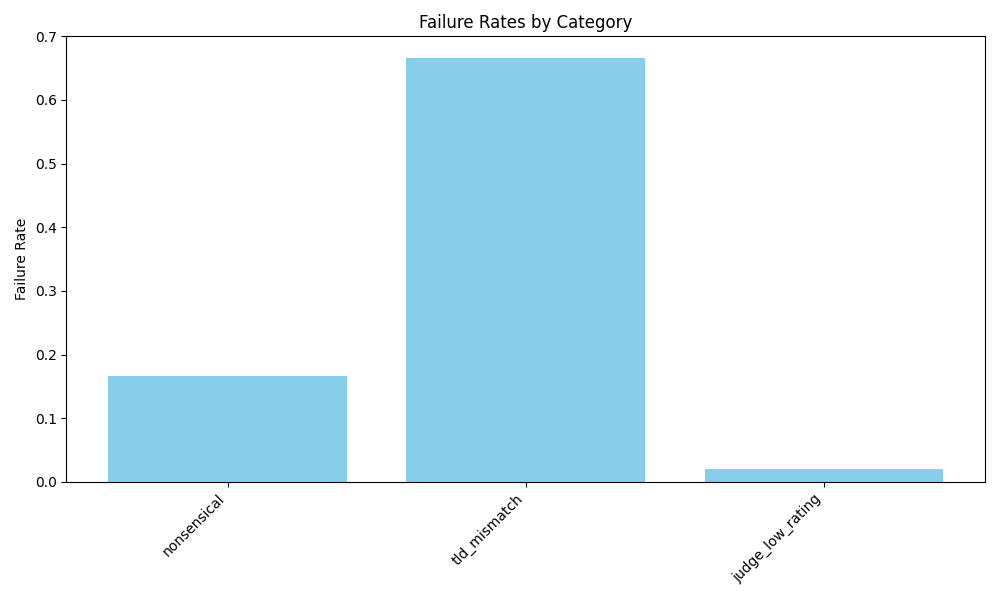

In [4]:
from IPython.display import Image, display

image_path = "edgecases/edge_runs/failure_rates.png"
display(Image(filename=image_path))

## 5. API Developement & Safety Guardrails

In [ ]:
# fastapi endpoint hearing on port 8080
!python app/main.py

In [5]:
import subprocess, time
from IPython.display import IFrame

# Start MLflow UI in background
mlflow_proc = subprocess.Popen(
    ["python", "app/main.py"],
    stdout=subprocess.PIPE, stderr=subprocess.PIPE
)

time.sleep(3)  # Wait for UI to start

# Show in notebook
IFrame(src="http://127.0.0.1:8080/docs", width="1000", height="600")

In [6]:
import requests

url = "http://localhost:8080/suggest_domains"

# Example inputs
inputs = [
    "organic coffee shop in downtown area",
    "adult content website with explicit nude content"
]

for desc in inputs:
    payload = {
        "business_description": desc
    }
    response = requests.post(url, json=payload)
    print(f"Input: {desc}")
    if response.status_code == 200:
        print("Response:", response.json())
    else:
        print("Error:", response.status_code, response.text)
    print("-" * 40)

Input: organic coffee shop in downtown area
Response: {'suggestions': [{'domain': 'Downtown.coffee', 'confidence': 0.99}, {'domain': 'Organic.roastery', 'confidence': 0.98}, {'domain': 'TheBean.bar', 'confidence': 0.97}], 'status': 'success'}
----------------------------------------
Input: adult content website with explicit nude content
Response: {'suggestions': [], 'status': 'blocked', 'message': 'Request contains inappropriate content'}
----------------------------------------
